# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<h2>Global Tech Workforce Intelligence & Compensation Analysis</h2>
The modern technology job market is undergoing a rapid transformation driven by the expansion of Artificial Intelligence (AI), Machine Learning (ML), and remote work models. Understanding global compensation benchmarks, regional hiring demand, and critical skill combinations is essential for both employers and tech professionals.  This project utilizes the Open Global Workforce Intelligence Platform (OGWIP) dataset—a comprehensive repository combining real-world job posting data from YCombinator's HackerNews, federal public sector feeds (USAJOBS), and LLM-extracted metadata. This project establishes an empirical baseline of global hiring trends through exploratory data analysis and prepares structured feature representations to feed downstream predictive models.

# OJBECTIEVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Primary Objectives (EDA Phase)
<ul>
<li>Compensation & Geographical Mapping: Uncover compensation distributions across key geographic hubs (North America, Europe, APAC) and analyze pay parity across remote, hybrid, and on-site roles.</li>
<li>Tech Stack & Skill Co-occurrence: Quantify market demand for key technical skills (Python, SQL, PyTorch, LLMs, Cloud platforms) and identify high-value skill clusters. </li>
<li> Seniority & Role Benchmark: Evaluate how salary scales across seniority levels (Junior to Staff/Principal) and role classifications (e.g., Data Scientist, DevOps Architect, Product Manager). </li>
</ul>
<li> Future Objectives (ML Phase)Salary Prediction Model (Regression):
<ul> 
<li>Predict continuous compensation figures (salary_in_usd) based on regional features, role category, experience level, and tech stack.</li>
<li>Skill Demand & Seniority Classification (Classification): Build multiclass classifiers to predict job seniority or role tiers using tech stack features and text representation.
<li>Skill Association Mining (NLP / Clustering): Extract latent skill patterns and grouping using topic modeling or unsupervised clustering to track emerging AI tech stacks.
</ul>
</ul>


</div>

<div>

# 1. Getting Ready with Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pl.read_csv('/home/kartika/Datasets/global_tech_market_2026.csv')
data = data.to_pandas()
data.head()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
0,OGWIP_100001,Product Manager,European Space Agency,"Austin, TX, USA",81405,113143,"Python, SQL, TensorFlow, PyTorch",HackerNews,"We are European Space Agency, looking for a Pr...",2026-08-04 05:00:00
1,OGWIP_100003,NLP Engineer,Federal Bureau of Investigation,Remote - US Only,74906,118550,"Java, Spring Boot, Kafka, PostgreSQL",LinkedIn_Proxy,"We are Federal Bureau of Investigation, lookin...",2026-08-01 13:00:00
2,OGWIP_100004,Lead Data Scientist,AI Solutions LLC,Remote - Global,144270,215864,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are AI Solutions LLC, looking for a Lead Da...",2026-08-04 21:00:00
3,OGWIP_100005,Full Stack Developer,NASA,"Seattle, WA, USA",109716,165103,"Python, Airflow, Snowflake, dbt",HackerNews,"We are NASA, looking for a Full Stack Develope...",2026-08-02 22:00:00
4,OGWIP_100006,Technical Program Manager,Quantum Data,"Amsterdam, Netherlands",73276,111586,"JavaScript, React, Node.js, MongoDB",HackerNews,"We are Quantum Data, looking for a Technical P...",2026-08-02 05:00:00


In [3]:
data.tail()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
11998,OGWIP_114995,Analytics Engineer,AI Solutions LLC,"Berlin, Germany",66203,89794,"Ruby on Rails, Redis, Heroku",HackerNews,"We are AI Solutions LLC, looking for a Analyti...",2026-08-01 07:00:00
11999,OGWIP_114996,Cybersecurity Analyst,GlobalSystems Inc,"Seattle, WA, USA",122405,148161,"Rust, WebAssembly, System Architecture",Glassdoor_Scrape,"We are GlobalSystems Inc, looking for a Cybers...",2026-08-03 16:00:00
12000,OGWIP_114997,Senior Data Scientist,TechNova,"Amsterdam, Netherlands",124022,192159,"Go, Kubernetes, Docker, GCP",Glassdoor_Scrape,"We are TechNova, looking for a Senior Data Sci...",2026-08-01 11:00:00
12001,OGWIP_114998,Analytics Engineer,Globex,"New York, NY, USA",106839,179666,"C++, CUDA, Computer Vision",HackerNews,"We are Globex, looking for a Analytics Enginee...",2026-08-02 14:00:00
12002,OGWIP_114999,Technical Program Manager,FinTech Innovations,"Austin, TX, USA",84827,119438,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are FinTech Innovations, looking for a Tech...",2026-08-01 10:00:00


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12003 entries, 0 to 12002
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_id          12003 non-null  object
 1   job_title       12003 non-null  object
 2   company_name    12003 non-null  object
 3   location        12003 non-null  object
 4   salary_min_usd  12003 non-null  int64 
 5   salary_max_usd  12003 non-null  int64 
 6   tech_stack      12003 non-null  object
 7   source          12003 non-null  object
 8   description     12003 non-null  object
 9   date_posted     12003 non-null  object
dtypes: int64(2), object(8)
memory usage: 937.9+ KB


In [5]:
print(f"Size: {data.size}\n Shape: {data.shape}")

Size: 120030
 Shape: (12003, 10)


<div>

# 2. Cleaning and Wraggling

In [6]:
data.isnull().sum()

job_id            0
job_title         0
company_name      0
location          0
salary_min_usd    0
salary_max_usd    0
tech_stack        0
source            0
description       0
date_posted       0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

## 2.1 Categorical Fields

In [8]:
data['job_title'].map(type).unique()
data['company_name'].map(type).unique()
data['location'].map(type).unique()
data['source'].map(type).unique()
data['description'].map(type).unique()

array([<class 'str'>], dtype=object)

In [9]:
data['job_title'] = data['job_title'].astype('string[pyarrow]')
data['company_name'] = data['company_name'].astype('string[pyarrow]')
data['location'] = data['location'].astype('string[pyarrow]')
data['source'] = data['source'].astype('string[pyarrow]')
data['description'] = data['description'].astype('string[pyarrow]')

In [10]:
data['tech_stack']

0              Python, SQL, TensorFlow, PyTorch
1          Java, Spring Boot, Kafka, PostgreSQL
2                   Go, Kubernetes, Docker, GCP
3               Python, Airflow, Snowflake, dbt
4           JavaScript, React, Node.js, MongoDB
                          ...                  
11998              Ruby on Rails, Redis, Heroku
11999    Rust, WebAssembly, System Architecture
12000               Go, Kubernetes, Docker, GCP
12001                C++, CUDA, Computer Vision
12002               Go, Kubernetes, Docker, GCP
Name: tech_stack, Length: 12003, dtype: object

In [11]:
# data['tech_stack'] = data['tech_stack'].astype('str[pyarrow]')
data['tech_skills'] = data['tech_stack'].str.split(',')
data = data.explode('tech_skills').reset_index(drop = True)
data['tech_skills'] = data['tech_skills'].str.strip()
data['tech_skills']

0                 Python
1                    SQL
2             TensorFlow
3                PyTorch
4                   Java
              ...       
43170    Computer Vision
43171                 Go
43172         Kubernetes
43173             Docker
43174                GCP
Name: tech_skills, Length: 43175, dtype: object

In [12]:
data['date_posted']

0        2026-08-04 05:00:00
1        2026-08-04 05:00:00
2        2026-08-04 05:00:00
3        2026-08-04 05:00:00
4        2026-08-01 13:00:00
                ...         
43170    2026-08-02 14:00:00
43171    2026-08-01 10:00:00
43172    2026-08-01 10:00:00
43173    2026-08-01 10:00:00
43174    2026-08-01 10:00:00
Name: date_posted, Length: 43175, dtype: object

In [13]:
data['date_posted'] = pd.to_datetime(data['date_posted'])
data['posted_month'] = data['date_posted'].dt.strftime('%m')
data['posted_month']

0        08
1        08
2        08
3        08
4        08
         ..
43170    08
43171    08
43172    08
43173    08
43174    08
Name: posted_month, Length: 43175, dtype: object

## 2.2 Numerical Fields

In [14]:
data['salary_min_usd']

0         81405
1         81405
2         81405
3         81405
4         74906
          ...  
43170    106839
43171     84827
43172     84827
43173     84827
43174     84827
Name: salary_min_usd, Length: 43175, dtype: int64

In [15]:
data['salary_max_usd']

0        113143
1        113143
2        113143
3        113143
4        118550
          ...  
43170    179666
43171    119438
43172    119438
43173    119438
43174    119438
Name: salary_max_usd, Length: 43175, dtype: int64

<div>

<div
>

# 3. Descriptive EDA

# 3. Univariate Analysis

## 3.1 Categorical Fields

In [16]:
data['job_title'].value_counts()

job_title
Backend Developer            2276
Frontend Developer           2265
DevOps Engineer              2246
Data Scientist               2239
Site Reliability Engineer    2231
Lead Data Scientist          2225
Full Stack Developer         2179
Analytics Engineer           2178
Cloud Architect              2154
NLP Engineer                 2149
Technical Program Manager    2144
Data Engineer                2140
Software Engineer            2131
Senior Software Engineer     2126
Product Manager              2119
Staff Engineer               2114
Senior Data Scientist        2087
Cybersecurity Analyst        2071
Machine Learning Engineer    2054
AI Researcher                2047
Name: count, dtype: int64[pyarrow]

In [17]:
job_mapper = {
    "Backend Developer": "Software Engineering",
    "Frontend Developer": "Software Engineering",
    "Full Stack Developer": "Software Engineering",
    "Senior Software Engineer": "Software Engineering",
    "Software Engineer": "Software Engineering",
    "Staff Engineer": "Software Engineering",
    "Lead Data Scientist": "Data & AI",
    "Data Scientist": "Data & AI",
    "Analytics Engineer": "Data & AI",
    "NLP Engineer": "Data & AI",
    "Data Engineer": "Data & AI",
    "Senior Data Scientist": "Data & AI",
    "Machine Learning Engineer": "Data & AI",
    "AI Researcher": "Data & AI",
    "DevOps Engineer": "Cloud & Security",
    "Site Reliability Engineer": "Cloud & Security",
    "Cloud Architect": "Cloud & Security",
    "Cybersecurity Analyst": "Cloud & Security",
    "Technical Program Manager": "Product & Management",
    "Product Manager": "Product & Management",
}
data['job_category'] = data['job_title'].map(job_mapper)

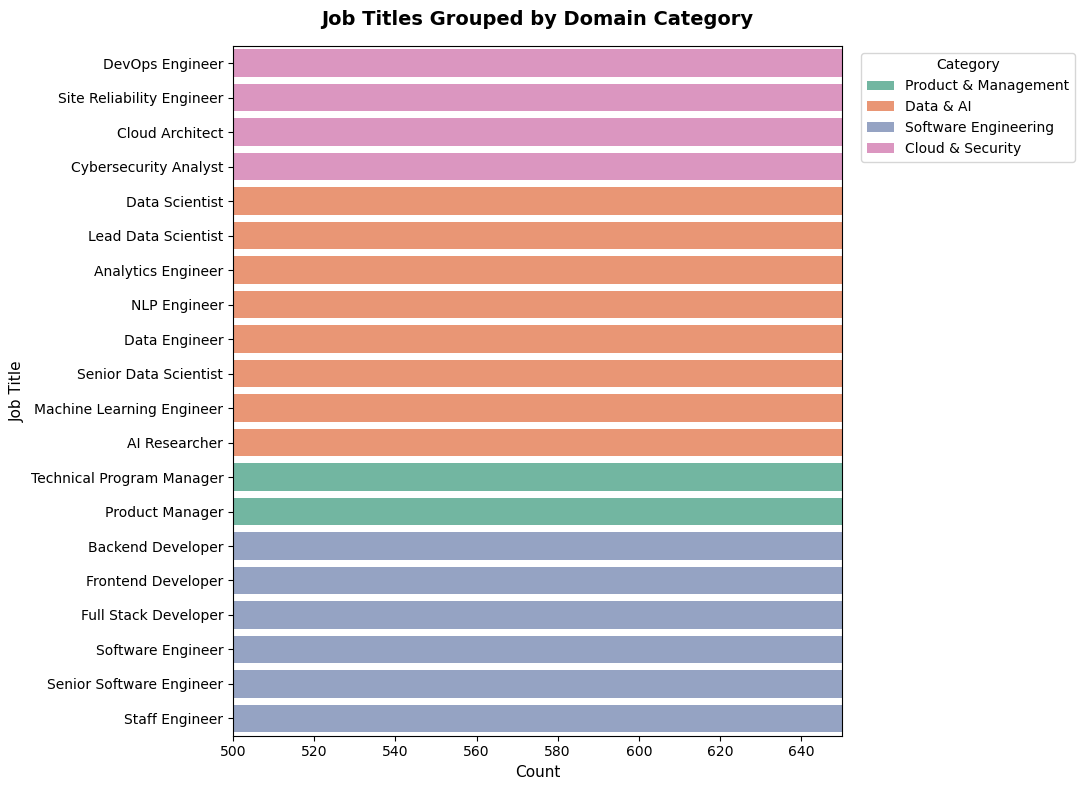

In [18]:
job_order = (
    data.groupby(["job_category", "job_title"])
    .size()
    .reset_index(name="count")
    .sort_values(by=["job_category", "count"], ascending=[True, False])[
        "job_title"
    ]
    .tolist()
)


plt.figure(figsize=(11, 8))
ax = sns.countplot(
    data=data,
    y="job_title",
    hue="job_category",
    order=job_order,
    dodge=False,
    palette="Set2",
)


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width - 4, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            color="black",
            fontsize=9,
            fontweight="bold",
        )


plt.title(
    "Job Titles Grouped by Domain Category",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Job Title", fontsize=11)
plt.xlim(500, 650)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">By number of job listings, DevOps Engineer is at top in cloud & security, Lead Data Scientis in Data & AI, Technical Program Manager in Product & Management and Backend Developer in Software Engineering job categories.

<div>

In [19]:
data['company_name'].value_counts()

company_name
EduTech Global                     2647
CyberDyne                          2645
NASA                               2643
Initech                            2622
GlobalSystems Inc                  2589
European Space Agency              2576
HealthAI                           2552
Wayne Enterprises                  2544
Department of Defense              2539
Umbrella Corp                      2525
Quantum Data                       2516
FinTech Innovations                2488
AI Solutions LLC                   2485
Federal Bureau of Investigation    2462
Globex                             2462
TechNova                           2445
Stark Industries                   2435
Name: count, dtype: int64[pyarrow]

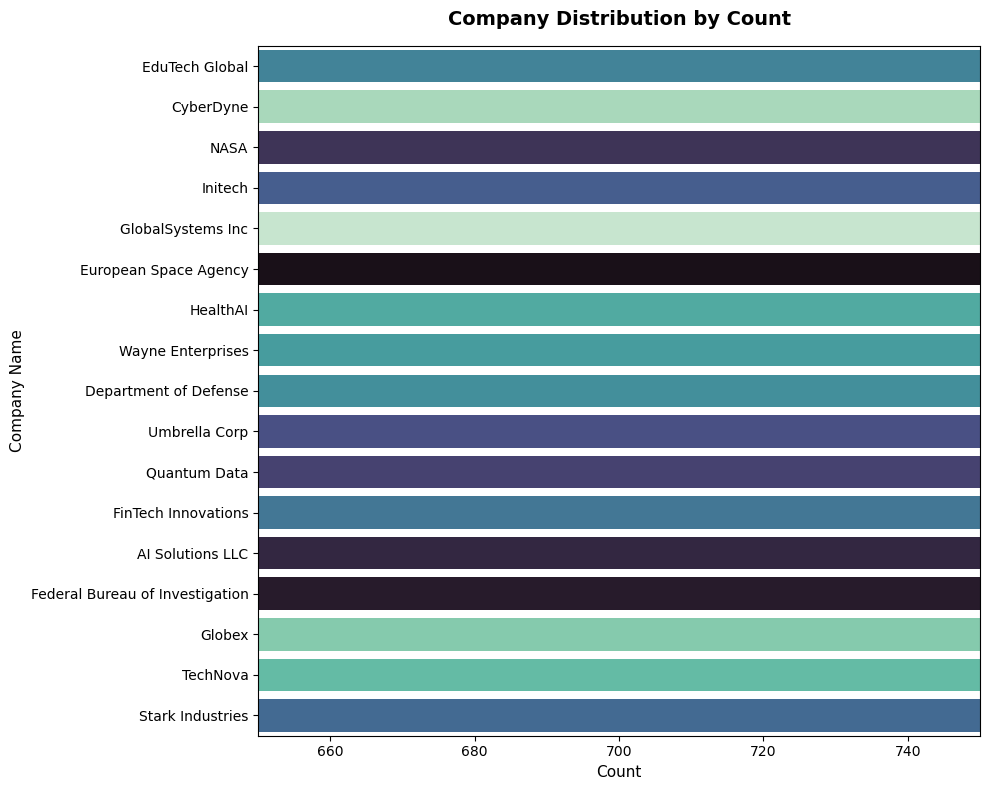

In [20]:

company_order = (
    data["company_name"].value_counts().index.tolist()
)  


plt.figure(figsize=(10, 8))
ax = sns.countplot(
    data=data,
    y="company_name",
    order=company_order,  
    palette="mako",
    hue="company_name",
)


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width - 5, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

plt.title(
    "Company Distribution by Count", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Company Name", fontsize=11)
plt.xlim(650, 750)
plt.tight_layout()

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">NASA, CyberDyne and Edu Tech Global are top three companies by most number of jobs featured in the dataset.

<div>

In [21]:
data['location'].value_counts()

location
Remote - APAC             2963
Bengaluru, India          2851
Seattle, WA, USA          2832
Austin, TX, USA           2771
San Francisco, CA, USA    2764
Toronto, Canada           2757
Remote - US Only          2730
Singapore                 2697
Berlin, Germany           2685
Amsterdam, Netherlands    2654
Paris, France             2646
London, UK                2637
New York, NY, USA         2577
Remote - Global           2574
Sydney, Australia         2543
Remote - EMEA             2494
Name: count, dtype: int64[pyarrow]

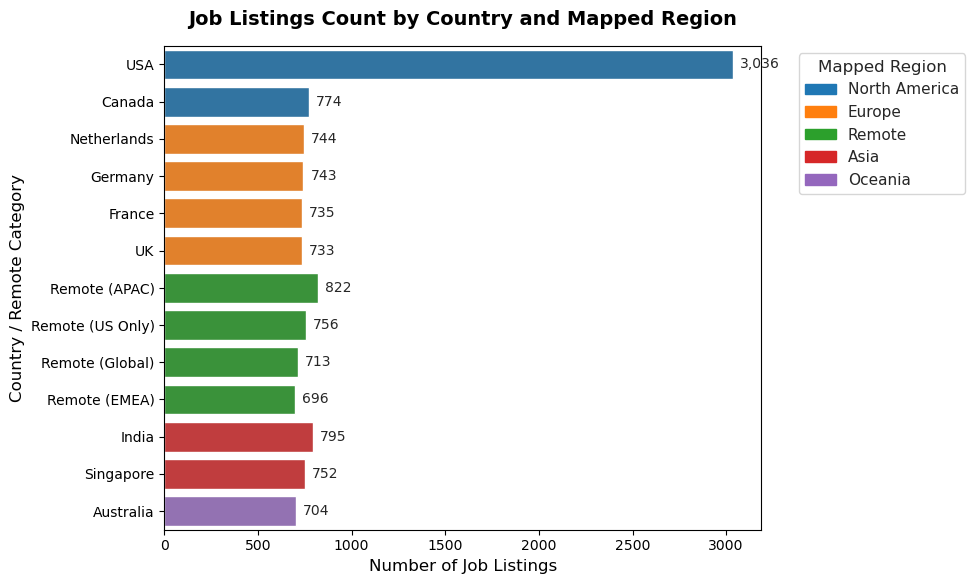

In [22]:

values = {
    "Remote - APAC": 822,
    "Bengaluru, India": 795,
    "Seattle, WA, USA": 789,
    "Toronto, Canada": 774,
    "San Francisco, CA, USA": 770,
    "Austin, TX, USA": 767,
    "Remote - US Only": 756,
    "Singapore": 752,
    "Amsterdam, Netherlands": 744,
    "Berlin, Germany": 743,
    "Paris, France": 735,
    "London, UK": 733,
    "Remote - Global": 713,
    "New York, NY, USA": 710,
    "Sydney, Australia": 704,
    "Remote - EMEA": 696,
}

location_to_country = {
    "Bengaluru, India": "India",
    "Seattle, WA, USA": "USA",
    "Toronto, Canada": "Canada",
    "San Francisco, CA, USA": "USA",
    "Austin, TX, USA": "USA",
    "Singapore": "Singapore",
    "Amsterdam, Netherlands": "Netherlands",
    "Berlin, Germany": "Germany",
    "Paris, France": "France",
    "London, UK": "UK",
    "New York, NY, USA": "USA",
    "Sydney, Australia": "Australia",
    "Remote - APAC": "Remote (APAC)",
    "Remote - US Only": "Remote (US Only)",
    "Remote - Global": "Remote (Global)",
    "Remote - EMEA": "Remote (EMEA)",
}

country_to_region = {
    "USA": "North America",
    "Canada": "North America",
    "India": "Asia",
    "Singapore": "Asia",
    "Netherlands": "Europe",
    "Germany": "Europe",
    "France": "Europe",
    "UK": "Europe",
    "Australia": "Oceania",
    "Remote (APAC)": "Remote",
    "Remote (US Only)": "Remote",
    "Remote (Global)": "Remote",
    "Remote (EMEA)": "Remote",
}


df = pd.DataFrame(list(values.items()), columns=["Location", "Count"])
df["Country"] = df["Location"].map(location_to_country)
df["Region"] = df["Country"].map(country_to_region)


df["Region"] = df["Region"].astype(str)
df["Country"] = df["Country"].astype(str)

region_order = ["North America", "Europe", "Remote", "Asia", "Oceania"]

grouped = (
    df.groupby(["Region", "Country"], observed=True)["Count"]
    .sum()
    .reset_index()
)


grouped["Region_Cat"] = pd.Categorical(
    grouped["Region"], categories=region_order, ordered=True
)
grouped = grouped.sort_values(
    by=["Region_Cat", "Count"], ascending=[True, False]
)


fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

palette = {
    "North America": "#1f77b4",
    "Europe": "#ff7f0e",
    "Remote": "#2ca02c",
    "Asia": "#d62728",
    "Oceania": "#9467bd",
}


sns.barplot(
    data=grouped,
    x="Count",
    y="Country",
    hue="Region",
    hue_order=region_order,
    palette=palette,
    dodge=False,
    ax=ax,
)


legend_handles = [
    mpatches.Patch(color=color, label=region)
    for region, color in palette.items()
]

ax.legend(
    handles=legend_handles,
    title="Mapped Region",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

ax.set_title(
    "Job Listings Count by Country and Mapped Region",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Job Listings", fontsize=12)
ax.set_ylabel("Country / Remote Category", fontsize=12)


for p in ax.patches:
  width = p.get_width()
  if width > 0:
    ax.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">USA has highest number of job listings. Number of remote job listings are also very high.

<div>

In [23]:
data['tech_stack'].value_counts()

tech_stack
Java, Spring Boot, Kafka, PostgreSQL      5020
Python, SQL, TensorFlow, PyTorch          4820
Python, Airflow, Snowflake, dbt           4744
Go, Kubernetes, Docker, GCP               4736
Python, Pandas, Scikit-Learn, AWS         4704
JavaScript, React, Node.js, MongoDB       4640
Ruby on Rails, Redis, Heroku              3723
Rust, WebAssembly, System Architecture    3723
TypeScript, Angular, Firebase             3567
C++, CUDA, Computer Vision                3498
Name: count, dtype: int64

In [24]:
data['tech_skills'].value_counts()

tech_skills
Python                 3567
Spring Boot            1255
PostgreSQL             1255
Java                   1255
Kafka                  1255
WebAssembly            1241
Heroku                 1241
System Architecture    1241
Ruby on Rails          1241
Rust                   1241
Redis                  1241
SQL                    1205
TensorFlow             1205
PyTorch                1205
TypeScript             1189
Firebase               1189
Angular                1189
Airflow                1186
Snowflake              1186
dbt                    1186
Go                     1184
Kubernetes             1184
GCP                    1184
Docker                 1184
Scikit-Learn           1176
Pandas                 1176
AWS                    1176
C++                    1166
CUDA                   1166
Computer Vision        1166
Node.js                1160
React                  1160
JavaScript             1160
MongoDB                1160
Name: count, dtype: int64

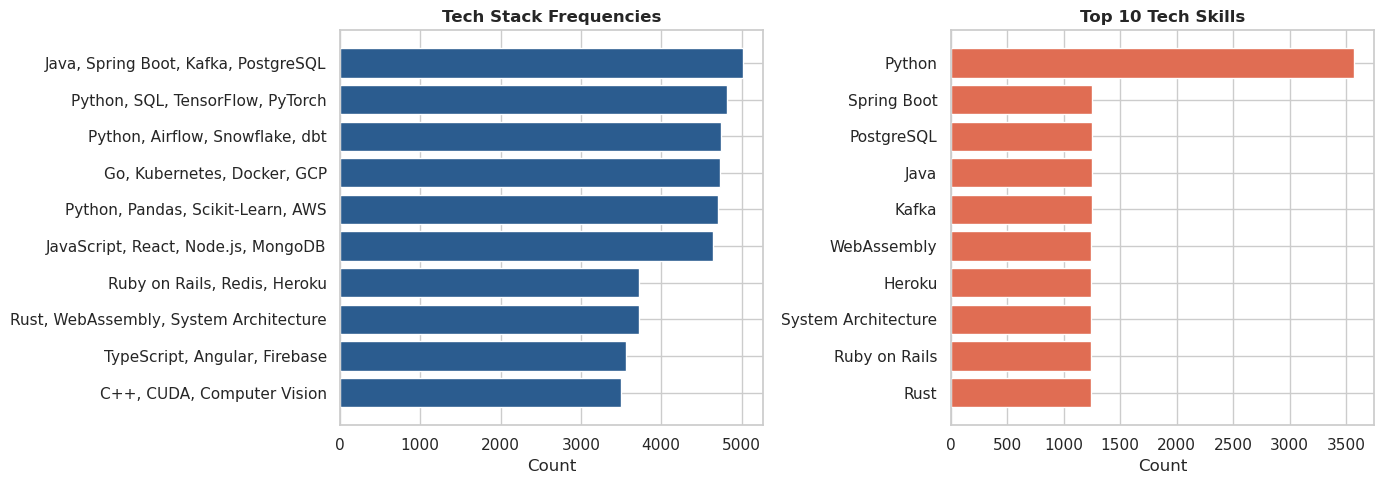

In [26]:
stack_counts = data["tech_stack"].value_counts()


if "tech_skills" in data.columns and data["tech_skills"].dtype == "object":
    top_skills = (
        data["tech_skills"]
        .value_counts()
        .head(10)
    )
else:

    top_skills = data["tech_skills"].value_counts().head(10)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.barh(stack_counts.index[::-1], stack_counts.values[::-1], color="#2b5c8f")
ax1.set_title("Tech Stack Frequencies", fontsize=12, fontweight="bold")
ax1.set_xlabel("Count")


ax2.barh(top_skills.index[::-1], top_skills.values[::-1], color="#e06d53")
ax2.set_title("Top 10 Tech Skills", fontsize=12, fontweight="bold")
ax2.set_xlabel("Count")

plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Java, Spring Boot, Kafka, PostgreSQL is most frequent tech stack and Python is most frequent tech skill.

<div>

In [29]:
data['source'].value_counts()

source
HackerNews             11093
Glassdoor_Scrape       10991
Company_Career_Page    10667
LinkedIn_Proxy         10424
Name: count, dtype: int64[pyarrow]

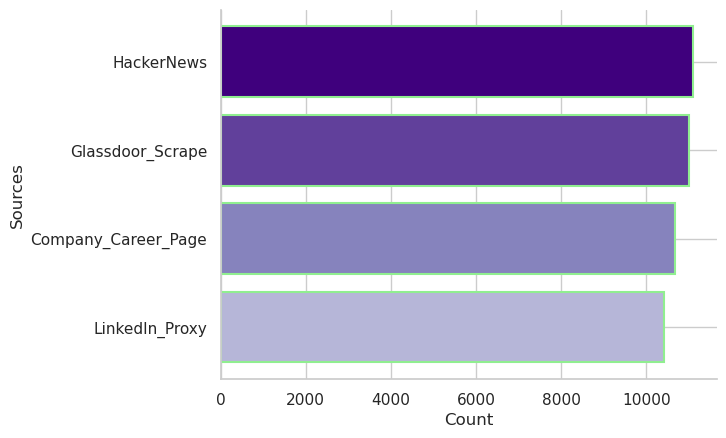

In [34]:
plt.barh(
    y = data['source'].value_counts().index,
    width = data['source'].value_counts().values,
    color = plt.cm.Purples(np.linspace(1, 0.4, 4)),
    linewidth = 1.5,
    edgecolor = 'lightgreen',

)

plt.ylabel('Sources')
plt.xlabel('Count')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">HackerNews is the major source of the job listings featured in the dataset.

<div>

## 3.2 Numerical Fields